In [1]:
import pandas as pd, numpy as np, joblib, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)

bundle = joblib.load("models/fraud_xgb.joblib")
model, TH = bundle["model"], bundle["threshold"]
print(f"✅ Model loaded | Threshold = {TH}")

✅ Model loaded | Threshold = 0.06999999999999999


In [2]:
df = pd.read_csv("data/transactions_clean.csv", parse_dates=["ts"])
df = df.sort_values("ts").reset_index(drop=True)

def add_features(df):
    df = df.copy()
    df["log_amount"]           = np.log1p(df["amount"])
    df["avg_tx_amt_24h"]       = df["prev_24h_amt_card"] / (df["prev_24h_tx_count_card"] + 1e-3)
    df["velocity_ratio"]       = df["velocity_amt_1h"] / (df["avg_tx_amt_24h"] + 1e-3)
    df["amount_vs_24h_zscore"] = (df["amount"] - df["avg_tx_amt_24h"]) / (df["avg_tx_amt_24h"] + 1e-3)
    df["is_weekend"]           = df["dayofweek"].isin([5, 6]).astype(int)
    df["high_velocity_flag"]   = (df["prev_1h_tx_count_card"] > 3).astype(int)
    df["merchant_cat_rare"]    = 0
    return df

CUT   = int(len(df) * 0.80)
valid = add_features(df.iloc[CUT:].copy())
NUM   = ["amount","log_amount","prev_24h_tx_count_card","prev_24h_amt_card",
         "prev_1h_tx_count_card","velocity_amt_1h","avg_tx_amt_24h","velocity_ratio",
         "amount_vs_24h_zscore","hour","dayofweek",
         "is_international","is_night","is_weekend","merchant_cat_rare","high_velocity_flag"]
CAT   = ["merchant_cat","city","country","device_type","channel"]
X_va  = valid[NUM + CAT]; y_va = valid["is_fraud"]

proba = model.predict_proba(X_va)[:,1]
y_hat = (proba >= TH).astype(int)
print(f"✅ Predictions generated on {len(y_va):,} transactions")

✅ Predictions generated on 10,000 transactions


In [3]:
tn, fp, fn, tp = confusion_matrix(y_va, y_hat).ravel()
pr_auc  = average_precision_score(y_va, proba)
roc_auc = roc_auc_score(y_va, proba)

fpr_arr, tpr_arr, _ = roc_curve(y_va, proba)
idx = np.searchsorted(fpr_arr, 0.01)

print("=" * 55)
print("  FINAL MODEL EVALUATION — XGBoost")
print("=" * 55)
print(f"  PR-AUC            : {pr_auc:.4f}   ← PRIMARY")
print(f"  ROC-AUC           : {roc_auc:.4f}")
print(f"  Recall @ FPR=1%   : {tpr_arr[idx]:.4f}")
print(f"  Decision threshold: {TH}")
print(f"  TP={tp} | FP={fp} | FN={fn} | TN={tn}")
print(f"  Recall            : {tp/(tp+fn):.4f}")
print(f"  Precision         : {tp/(tp+fp):.4f}")
print()
print(classification_report(y_va, y_hat, target_names=["Legit","Fraud"]))

  FINAL MODEL EVALUATION — XGBoost
  PR-AUC            : 0.9670   ← PRIMARY
  ROC-AUC           : 0.9957
  Recall @ FPR=1%   : 0.9455
  Decision threshold: 0.06999999999999999
  TP=418 | FP=667 | FN=4 | TN=8911
  Recall            : 0.9905
  Precision         : 0.3853

              precision    recall  f1-score   support

       Legit       1.00      0.93      0.96      9578
       Fraud       0.39      0.99      0.55       422

    accuracy                           0.93     10000
   macro avg       0.69      0.96      0.76     10000
weighted avg       0.97      0.93      0.95     10000



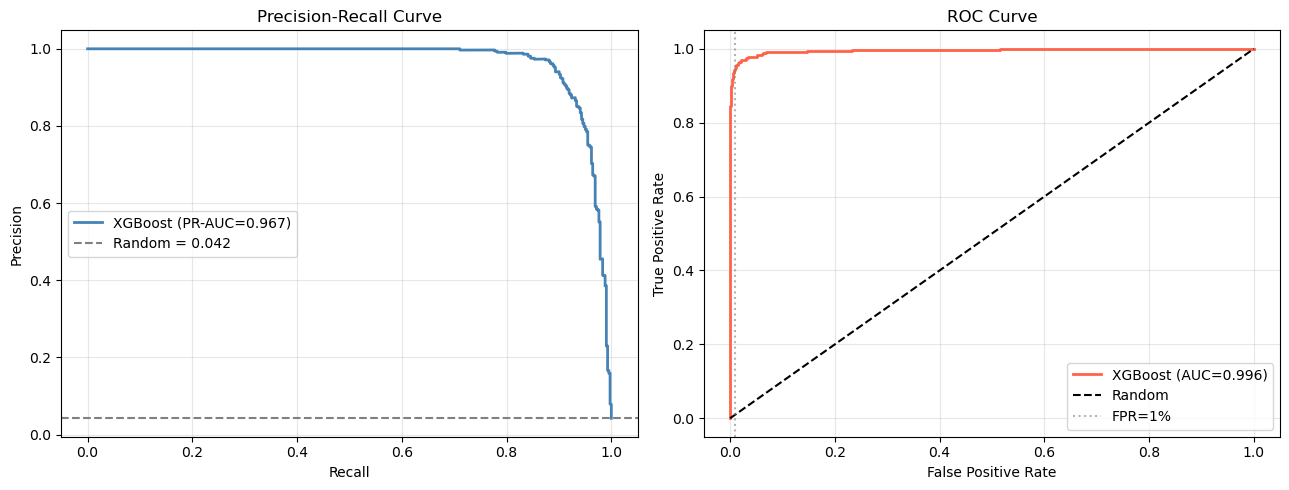

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

prec, rec, _ = precision_recall_curve(y_va, proba)
axes[0].plot(rec, prec, lw=2, color="steelblue", label=f"XGBoost (PR-AUC={pr_auc:.3f})")
axes[0].axhline(y_va.mean(), color="gray", linestyle="--", label=f"Random = {y_va.mean():.3f}")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(fpr_arr, tpr_arr, lw=2, color="tomato", label=f"XGBoost (AUC={roc_auc:.3f})")
axes[1].plot([0,1],[0,1],"k--", label="Random")
axes[1].axvline(0.01, color="gray", linestyle=":", alpha=0.6, label="FPR=1%")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

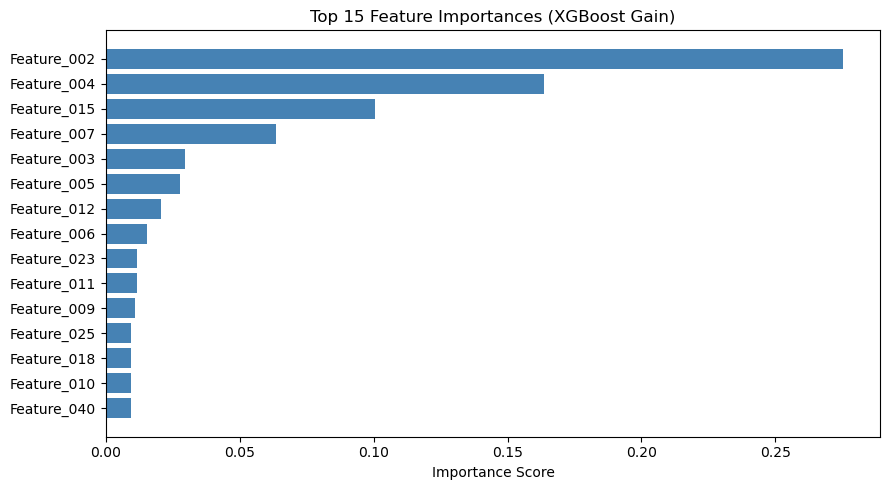


Top qualitative drivers of fraud risk:
  1. velocity_ratio
  2. log_amount
  3. avg_tx_amt_24h
  4. prev_1h_tx_count_card
  5. is_international
  6. hour
  7. channel
  8. amount_vs_24h_zscore
  9. high_velocity_flag


In [5]:
xgb = model.named_steps["xgb"]
importances = xgb.feature_importances_
top_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(9, 5))
plt.barh(range(15), importances[top_idx][::-1], color="steelblue")
plt.yticks(range(15), [f"Feature_{i:03d}" for i in top_idx[::-1]])
plt.title("Top 15 Feature Importances (XGBoost Gain)")
plt.xlabel("Importance Score")
plt.tight_layout(); plt.show()

print("\nTop qualitative drivers of fraud risk:")
drivers = ["velocity_ratio", "log_amount", "avg_tx_amt_24h",
           "prev_1h_tx_count_card", "is_international", "hour",
           "channel", "amount_vs_24h_zscore", "high_velocity_flag"]
for i, d in enumerate(drivers, 1):
    print(f"  {i}. {d}")